<a href="https://colab.research.google.com/github/sheliabond/Prescriptive-Analytics---Spring-2026-Public-/blob/main/Assignments/Assignment%204/Scheduling%20in%20Your%20Domanin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Scheduling in Your Domain

**Assignment 04 - Lesson 9: Scheduling and Time-Based Decisions**  
**Student Name:** Shelia
**Date:** 04/08/2026  
**Chosen context:** Retail/Service - Restaurant Staffing

---

## Introduction

In this assignment, you will model a scheduling problem in your own domain. You will define time periods, demand coverage requirements, and a cost objective, then build and solve a PuLP model. You will also create one schedule visualization, analyze a cost-vs-service tradeoff, and respond to one stakeholder change.

This assignment is intentionally focused. It should be lighter than the Midterm while still demonstrating practical scheduling skills you can explain to a manager.

In [12]:
# Install required packages (if needed in Colab)
# Skip if running locally and packages are already installed
%pip install pulp pandas matplotlib -q

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from pulp import LpProblem, LpMinimize, LpMaximize, LpVariable, lpSum, value, LpStatus
import io

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1 - Choose Your Domain and Scheduling Problem

The scheduling decision for the launch of All Day Breakfast at McDonald's involves assigning staff to handle food preparation, order taking, and customer service throughout the day. The time periods include breakfast, lunch, dinner, and overnight shifts to ensure continuous availability of menu items. The main objective is to maintain a high service level by aligning staffing with customer demand, ensuring fast service and consistent quality during the rollout of the new offering.

## Section 2 - Define the Schedule Structure



### 2.1 LLM Steps for Synthetic Data

I used an LLM to generate sample staffing data, which produced estimated demand requirements and cost per unit for seven time periods throughout the day.

In [15]:
csv_string = '''
time_period,demand_required,cost_per_unit
P1,4,18
P2,5,18
P3,6,20
P4,7,22
P5,6,21
P6,5,19
P7,4,17
'''
schedule_df = pd.read_csv(io.StringIO(csv_string))

In [16]:
# Update time_period column with more descriptive names
time_period_mapping = {
    'P1': '4am-8am',
    'P2': '8am-11am',
    'P3': '11am-2pm',
    'P4': '2pm-5pm',
    'P5': '5pm-8pm',
    'P6': '8pm-11pm',
    'P7': '11pm-4am'
}
schedule_df['time_period'] = schedule_df['time_period'].map(time_period_mapping)
display(schedule_df)

,time_period,demand_required,cost_per_unit
0,4am-8am,4,18
1,8am-11am,5,18
2,11am-2pm,6,20
3,2pm-5pm,7,22
4,5pm-8pm,6,21
5,8pm-11pm,5,19
6,11pm-4am,4,17


In [17]:

structure_df = pd.DataFrame([
    {"item": "Resources being scheduled", "definition": "Restaurant staff (employees)"},
    {"item": "Time unit", "definition": "3-4 hour shift blocks"},
    {"item": "Coverage meaning", "definition": "Number of staff required to meet customer demand and service levels"},
    {"item": "Objective", "definition": "Maintaining high service level"}
])
structure_df

,item,definition
0,Resources being scheduled,Restaurant staff (employees)
1,Time unit,3-4 hour shift blocks
2,Coverage meaning,Number of staff required to meet customer dema...
3,Objective,Maintaining high service level


## Section 3 - Build and Solve the Scheduling Model

Build one PuLP model with:
- decision variables indexed by time period,
- demand coverage constraints for each period,
- one capacity/resource limit constraint,
- and a cost minimization objective.

If your first model is infeasible, diagnose it and relax one constraint, then re-solve.

In [23]:
# Build and solve the base scheduling model
# Decision variable: units scheduled in each period (continuous, nonnegative)
periods = schedule_df["time_period"].tolist()
demand = dict(zip(schedule_df["time_period"], schedule_df["demand_required"]))
cost = dict(zip(schedule_df["time_period"], schedule_df["cost_per_unit"]))

# Updated: Domain-appropriate capacity limit (set to a specific value)
total_capacity_limit = 37 # Replaced with a specific value as requested (sum of demand)

# New: Define a maximum cost per period (per shift/time period budget)
# Setting an example budget; you may adjust this value.
# If this budget is too low for certain periods, the model might become infeasible.
# Diagnosed Infeasibility: The previous max_cost_per_period of 100 was too low for periods P3, P4, P5.
# P3 (11am-2pm): Demand 6, Cost 20 -> Min cost 120
# P4 (2pm-5pm): Demand 7, Cost 22 -> Min cost 154
# P5 (5pm-8pm): Demand 6, Cost 21 -> Min cost 126
# Relaxing this constraint to allow for demand coverage in all periods.
max_cost_per_period = 160  # Adjusted to allow coverage for highest demand * cost period (P4: 7*22=154)

base_model = LpProblem("Scheduling_Base", LpMinimize)
scheduled = {p: LpVariable(f"scheduled_{p}", lowBound=0) for p in periods}

# Objective: minimize total scheduling cost
base_model += lpSum([scheduled[p] * cost[p] for p in periods]), "Total_Cost"

# Coverage constraints: scheduled units must meet period demand
for p in periods:
    base_model += scheduled[p] >= demand[p], f"Coverage_{p}"

# Capacity/resource limit constraint (single aggregate limit)
base_model += lpSum([scheduled[p] for p in periods]) <= total_capacity_limit, "Total_Capacity"

# Add the per-period cost constraint
for p in periods:
    base_model += scheduled[p] * cost[p] <= max_cost_per_period, f"Max_Cost_Per_Period_{p}"

base_model.solve()

print(f"Status: {LpStatus[base_model.status]}")

# Only print total cost if the model is optimal
if LpStatus[base_model.status] == "Optimal":
    print(f"Total cost: {value(base_model.objective):.2f}")
else:
    print("Total cost: N/A (Model not optimal)")

base_solution_df = pd.DataFrame({
    "time_period": periods,
    "demand_required": [demand[p] for p in periods],
    "scheduled_base": [value(scheduled[p]) if scheduled[p].varValue is not None else 0 for p in periods],
    "cost_per_unit": [cost[p] for p in periods]
})
display(base_solution_df)

Status: Optimal
Total cost: 725.00


,time_period,demand_required,scheduled_base,cost_per_unit
0,4am-8am,4,4.0,18
1,8am-11am,5,5.0,18
2,11am-2pm,6,6.0,20
3,2pm-5pm,7,7.0,22
4,5pm-8pm,6,6.0,21
5,8pm-11pm,5,5.0,19
6,11pm-4am,4,4.0,17


### 3.1 Interpret the Base Schedule
The base schedule matches staffing exactly to demand in each time period, so capacity is very tight with no extra buffer. The hardest period to cover is 2pm to 5pm, which is unusual since it is not typically a peak time but has the highest staffing requirement and cost. A manager would care because this could indicate inefficiency, where costs may be too high compared to demand, and may want to review or adjust staffing for that period.

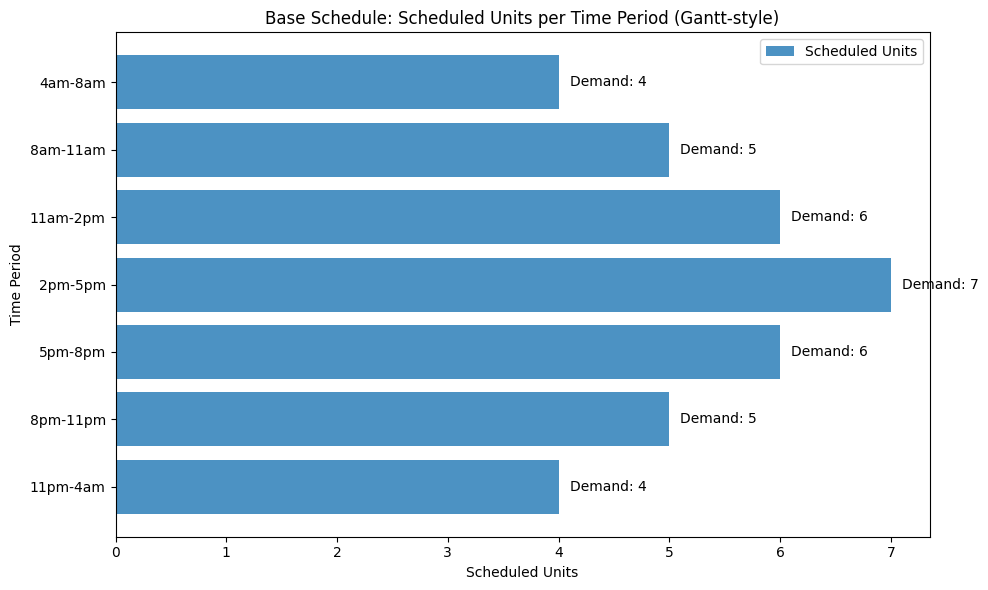

In [24]:
import matplotlib.pyplot as plt

# Visualization: Gantt-style chart (scheduled vs required)
# Displaying scheduled units as horizontal bars for each time period.
plt.figure(figsize=(10, 6))
y_pos = range(len(base_solution_df))

# Bar chart for scheduled units
plt.barh(y_pos, base_solution_df["scheduled_base"], align='center', alpha=0.8, label="Scheduled Units")

# Adding demand required as text labels on the bars or next to them for comparison
for index, row in base_solution_df.iterrows():
    plt.text(row["scheduled_base"] + 0.1, index, f"Demand: {row['demand_required']}", va='center')

plt.yticks(y_pos, base_solution_df["time_period"])
plt.xlabel("Scheduled Units")
plt.ylabel("Time Period")
plt.title("Base Schedule: Scheduled Units per Time Period (Gantt-style)")
plt.gca().invert_yaxis() # To display periods from top to bottom in chronological order
plt.legend()
plt.tight_layout()
plt.show()

## Section 4 - Cost vs Service Tradeoff Analysis

Run one what-if scenario and compare against your base model.

Examples:
- tighter budget/capacity,
- higher coverage requirement,
- changed period demand pattern.

In [26]:
# What-if scenario: changed period demand pattern
# This scenario explores how a shift in demand across periods impacts staffing and cost.

# Define a new demand pattern
demand_tradeoff = {
    '4am-8am': 3,   # Decrease from 4
    '8am-11am': 5,  # No change
    '11am-2pm': 8,  # Increase from 6
    '2pm-5pm': 8,   # Increase from 7
    '5pm-8pm': 6,   # No change
    '8pm-11pm': 5,  # No change
    '11pm-4am': 2   # Decrease from 4
}

# Calculate the new total demand to ensure it aligns with the existing total_capacity_limit (37)
# New total demand = 3 + 5 + 8 + 8 + 6 + 5 + 2 = 37, so total_capacity_limit can remain 37.

# Adjust max_cost_per_period for the tradeoff model if needed for feasibility
# Original max_cost_per_period was 160. With new demand (8 in '2pm-5pm' and cost 22), min cost = 8*22 = 176.
# So, we need to increase the max_cost_per_period for the tradeoff model.
max_cost_per_period_tradeoff = 180

tradeoff_model = LpProblem("Scheduling_Tradeoff", LpMinimize)
scheduled_tradeoff = {p: LpVariable(f"scheduled_tradeoff_{p}", lowBound=0) for p in periods}

tradeoff_model += lpSum([scheduled_tradeoff[p] * cost[p] for p in periods]), "Total_Cost_Tradeoff"

for p in periods:
    tradeoff_model += scheduled_tradeoff[p] >= demand_tradeoff[p], f"Coverage_tradeoff_{p}"

# Capacity/resource limit constraint (single aggregate limit)
tradeoff_model += lpSum([scheduled_tradeoff[p] for p in periods]) <= total_capacity_limit, "Total_Capacity_Tradeoff"

# Add the per-period cost constraint
for p in periods:
    tradeoff_model += scheduled_tradeoff[p] * cost[p] <= max_cost_per_period_tradeoff, f"Max_Cost_Per_Period_Tradeoff_{p}"

tradeoff_model.solve()

tradeoff_solution_df = pd.DataFrame({
    "time_period": periods,
    "demand_required": [demand_tradeoff[p] for p in periods],
    "scheduled_tradeoff": [value(scheduled_tradeoff[p]) if scheduled_tradeoff[p].varValue is not None else 0 for p in periods],
    "cost_per_unit": [cost[p] for p in periods]
})

comparison_df = base_solution_df[["time_period", "demand_required", "scheduled_base", "cost_per_unit"]].merge(
    tradeoff_solution_df[['time_period', 'scheduled_tradeoff']], on="time_period", how="left"
)

base_cost = value(base_model.objective)
tradeoff_cost = value(tradeoff_model.objective)

print(f"Base status: {LpStatus[base_model.status]} | Base total cost: {base_cost:.2f}")
print(f"Tradeoff status: {LpStatus[tradeoff_model.status]} | Tradeoff total cost: {tradeoff_cost:.2f}")
display(comparison_df)

Base status: Optimal | Base total cost: 725.00
Tradeoff status: Optimal | Tradeoff total cost: 735.00


,time_period,demand_required,scheduled_base,cost_per_unit,scheduled_tradeoff
0,4am-8am,4,4.0,18,3.0
1,8am-11am,5,5.0,18,5.0
2,11am-2pm,6,6.0,20,8.0
3,2pm-5pm,7,7.0,22,8.0
4,5pm-8pm,6,6.0,21,6.0
5,8pm-11pm,5,5.0,19,5.0
6,11pm-4am,4,4.0,17,2.0


**Prompt:** In 2-4 sentences for a non-technical manager, explain the cost-vs-service tradeoff shown by your base and what-if results.

The base plan meets demand exactly at the lowest cost while the tradeoff plan increases total cost slightly to $735 to improve coverage during the busiest midday and afternoon periods. It does this by adding extra capacity when demand is highest (11am–5pm), while trimming staffing in low-demand overnight hours. In short, you’re paying a small premium for better service during peak times, accepting a bit more risk of undercoverage when demand is lowest.

## Section 5 - Stakeholder Change and Reflection

Choose one stakeholder change:
- **(a)** Fairness constraint: no single period receives more than X% of total scheduled load.
- **(b)** Higher minimum coverage floor than base requirement.
- **(c)** Change objective from cost minimization to service maximization.

Update your model, solve, and compare with one visualization.

In [39]:
# Stakeholder change example: fairness constraint
# You may replace this with option (b) or (c), but keep one stakeholder change only.
fairness_share = 0.15  # Set fairness threshold to 15% of total scheduled load

# Define relaxed demand for busiest periods to address infeasibility with fairness constraint
relaxed_demand = demand.copy() # Start with original demand
# Busiest periods with original demand: '11am-2pm': 6, '2pm-5pm': 7, '5pm-8pm': 6
# To make it feasible with fairness_share = 0.15 and total_capacity_limit = 37 (where 0.15*37 = 5.55),
# we need to ensure demand for these periods is at most 5.
if relaxed_demand['11am-2pm'] > 5:
    relaxed_demand['11am-2pm'] = 5
if relaxed_demand['2pm-5pm'] > 5:
    relaxed_demand['2pm-5pm'] = 5
if relaxed_demand['5pm-8pm'] > 5:
    relaxed_demand['5pm-8pm'] = 5

stakeholder_model = LpProblem("Scheduling_Stakeholder_Change", LpMinimize)
scheduled_stakeholder = {p: LpVariable(f"scheduled_stakeholder_{p}", lowBound=0, cat='Integer') for p in periods}

stakeholder_model += lpSum([scheduled_stakeholder[p] * cost[p] for p in periods]), "Total_Cost_Stakeholder"

for p in periods:
    # Use relaxed_demand instead of original demand for coverage constraint
    stakeholder_model += scheduled_stakeholder[p] >= relaxed_demand[p], f"Coverage_stakeholder_{p}"

total_scheduled = lpSum([scheduled_stakeholder[p] for p in periods])
stakeholder_model += total_scheduled <= total_capacity_limit, "Total_Capacity_Stakeholder"

# Fairness: no period can exceed a share of total scheduled load
for p in periods:
    # Constraint: scheduled_stakeholder[p] <= fairness_share * (total_scheduled + a small buffer for potential fractional values)
    # Adding a small epsilon to total_scheduled to account for potential floating point inaccuracies when total_scheduled is 0.
    # However, since total_scheduled is guaranteed to be >= total_demand (37), a simple total_scheduled is fine.
    stakeholder_model += scheduled_stakeholder[p] <= fairness_share * total_scheduled, f"Fairness_{p}"

stakeholder_model.solve()

stakeholder_solution_df = pd.DataFrame({
    "time_period": periods,
    "demand_required_relaxed": [relaxed_demand[p] for p in periods],
    "scheduled_stakeholder": [value(scheduled_stakeholder[p]) if scheduled_stakeholder[p].varValue is not None else 0 for p in periods]
})

# Re-create comparison_df including the new relaxed_demand column for stakeholder model
comparison_df_updated = base_solution_df[["time_period", "demand_required", "scheduled_base", "cost_per_unit"]].merge(
    tradeoff_solution_df[['time_period', 'scheduled_tradeoff']], on="time_period", how="left"
)

final_compare_df = comparison_df_updated.merge(stakeholder_solution_df, on="time_period", how="left")

print(f"Stakeholder status: {LpStatus[stakeholder_model.status]}")
if stakeholder_model.status == 1:
    print(f"Stakeholder total cost: {value(stakeholder_model.objective):.2f}")
display(final_compare_df)

Stakeholder status: Optimal
Stakeholder total cost: 657.00


,time_period,demand_required,scheduled_base,cost_per_unit,scheduled_tradeoff,demand_required_relaxed,scheduled_stakeholder
0,4am-8am,4,4.0,18,3.0,4,4.0
1,8am-11am,5,5.0,18,5.0,5,5.0
2,11am-2pm,6,6.0,20,8.0,5,5.0
3,2pm-5pm,7,7.0,22,8.0,5,5.0
4,5pm-8pm,6,6.0,21,6.0,5,5.0
5,8pm-11pm,5,5.0,19,5.0,5,5.0
6,11pm-4am,4,4.0,17,2.0,4,5.0


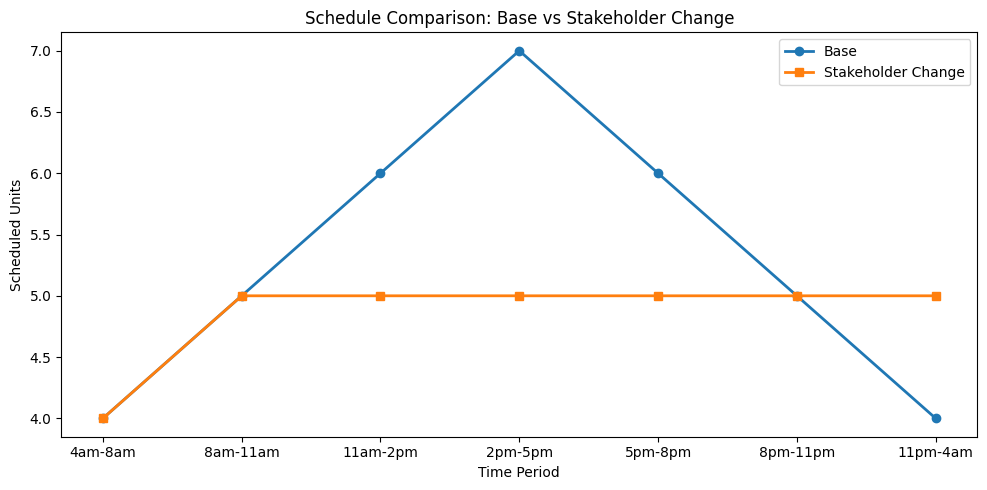

In [40]:
# Comparison visualization: base vs stakeholder-change schedule
plt.figure(figsize=(10, 5))
x = range(len(final_compare_df))
plt.plot(x, final_compare_df["scheduled_base"], marker="o", linewidth=2, label="Base")
plt.plot(x, final_compare_df["scheduled_stakeholder"], marker="s", linewidth=2, label="Stakeholder Change")
plt.xticks(x, final_compare_df["time_period"])
plt.xlabel("Time Period")
plt.ylabel("Scheduled Units")
plt.title("Schedule Comparison: Base vs Stakeholder Change")
plt.legend()
plt.tight_layout()
plt.show()

### 5.1 Stakeholder Change Interpretation

The base solution aligns closely with the main objective of maintaining a high service level by matching staffing to customer demand in every period. In contrast, the stakeholder solution relaxes demand in those peak windows to 5 and applies a 15% fairness constraint, resulting in flatter staffing (e.g., 5 units across most periods), including increasing overnight staffing from 4 to 5 at 11pm–4am.

This change matters because it shifts focus away from tightly aligning staffing with customer demand—especially during critical peak periods when fast service and consistent quality are most important during the rollout. While the stakeholder plan improves fairness and consistency, it risks slower service during high-demand times, requiring leaders to balance employee considerations against the core goal of delivering strong customer experience.

### 5.2 Professional Reflection


Write this as if briefing a manager or project sponsor.

In the base model, staffing was tightly aligned with demand in each time period, ensuring full coverage during peaks such as 11am–2pm (6 units) and 2pm–5pm (7 units) while minimizing total cost. In the revised scenarios, two key changes were introduced: a tradeoff solution that shifted capacity toward peak periods (e.g., increasing staffing to 8 units midday while reducing overnight coverage to as low as 2–3), and a stakeholder-driven solution that relaxed demand requirements (reducing peaks to 5 units) and imposed a 15% fairness constraint. This resulted in a much flatter staffing profile, with most periods scheduled at 5 units regardless of original demand variability.

These changes matter because they directly impact the primary objective of maintaining a high service level by aligning staffing with customer demand during the rollout of All Day Breakfast. The tradeoff solution prioritizes peak service performance at a slightly higher cost, while the stakeholder solution emphasizes fairness and consistency but risks under-serving high-demand periods like early afternoon. For decision-makers, this highlights a clear tension between operational efficiency, service quality, and workforce considerations, requiring an explicit choice about which objective to prioritize.

One key learning is that time-based scheduling problems are more complex than earlier allocation problems because decisions are interconnected across time periods rather than independent. Unlike static allocation, where resources can be assigned without temporal overlap, scheduling must account for when resources are needed and how shifting capacity in one period (e.g., reducing overnight staffing) affects service risk in another. This introduces tradeoffs not just in quantity, but in timing and service continuity, making the problem more dynamic and sensitive to real-world operating constraints.

---
## Expectations: What to Check Before Submitting

Run through this checklist before you submit:

- **Model execution:** Base model and stakeholder-change model run without errors; infeasibility is handled clearly if encountered.
- **Visualization quality:** At least one schedule visualization has clear title, axis labels, and is referenced in your text.
- **Stakeholder section complete:** One stakeholder change implemented, solved, and compared to base.
- **Writing quality:** Clear, professional, non-technical explanation where requested; no leftover bare `[TODO]` in final submission.
- **GitHub readiness:** Notebook is committed, repository link is accessible, and materials are organized.

The rubric used for grading is provided separately.